# Elasticidade-Preço da Demanda — Online Retail II (UCI)

**Objetivo:** estimar a elasticidade-preço da demanda de produtos reais de uma loja de
presentes online (Reino Unido, 2009–2011) — a mesma pergunta do projeto de Precificação Dinâmica
(elasticidade em e-commerce), mas com um dataset diferente, escolhido especificamente por ter
sinal de preço genuíno.

**Por que trocar de dataset:** um teste rápido de correlação preço x quantidade nos produtos
mais vendidos deu resultados consistentemente negativos (-0,20 a -0,79) — bem diferente do
dataset usado antes, onde o preço praticamente não variava por produto. Esse teste (feito
**antes** de montar o notebook inteiro) é o que justifica investir tempo nesse dataset.

**Dataset:** [Online Retail II (UCI)](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)
— mais de 1 milhão de transações reais, ~5.300 produtos distintos.

## 1. Importação e carregamento dos dados

Arquivo grande (~95MB, 1M+ linhas) — carregamento direto via pandas, sem necessidade de
otimização especial pra esse volume.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('online_retail_II.csv')
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Visão geral do dataset

In [2]:
print(data.shape)
data.info()
print(f"\nPeríodo: {data['InvoiceDate'].min()} até {data['InvoiceDate'].max()}")
print(f"Produtos únicos (StockCode): {data['StockCode'].nunique()}")
print(f"Países: {data['Country'].nunique()}")

(1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB

Período: 2009-12-01 07:45:00 até 2011-12-09 12:50:00
Produtos únicos (StockCode): 5305
Países: 43


## 3. Inconsistências e problemas de qualidade

Dataset transacional real de e-commerce tem uma lista conhecida de problemas — confirmando cada
um antes de decidir o que fazer com eles.

In [3]:
print(f"Valores nulos:\n{data.isnull().sum()}\n")
print(f"Linhas duplicadas: {data.duplicated().sum()}")
print(f"Faturas canceladas (Invoice começa com 'C'): {data['Invoice'].astype(str).str.startswith('C').sum()}")
print(f"Quantity <= 0 (devoluções/erros): {(data['Quantity'] <= 0).sum()}")
print(f"Price <= 0: {(data['Price'] <= 0).sum()}")

codigos_nao_produto = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'C2', 'PADS', 'ADJUST', 'ADJUST2', 'SAMPLES']
print(f"\nLinhas com códigos que não são produtos reais (frete, taxas, ajustes):")
print(data[data['StockCode'].isin(codigos_nao_produto)]['StockCode'].value_counts())

Valores nulos:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Linhas duplicadas: 34335
Faturas canceladas (Invoice começa com 'C'): 19494
Quantity <= 0 (devoluções/erros): 22950
Price <= 0: 6207

Linhas com códigos que não são produtos reais (frete, taxas, ajustes):
StockCode
POST            2122
DOT             1446
M               1421
C2               282
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
PADS              19
CRUK              16
ADJUST2            3
Name: count, dtype: int64


## 4. Tratamento dos dados

**Decisões:**
- Faturas canceladas (`C...`): removo — não representam venda real.
- `Quantity <= 0`: removo — devoluções/estornos, não é demanda positiva.
- `Price <= 0`: removo — brinde/erro de cadastro, não é preço de venda real.
- Códigos que não são produtos (`POST`, `DOT`, `BANK CHARGES`...): removo — são frete/taxa
  disfarçados de "produto", não fazem parte da pergunta de elasticidade.
- Duplicatas exatas: removo.

In [4]:
antes = len(data)

data_clean = data[
    (~data['Invoice'].astype(str).str.startswith('C')) &
    (data['Quantity'] > 0) &
    (data['Price'] > 0) &
    (~data['StockCode'].isin(codigos_nao_produto))
].drop_duplicates().copy()

data_clean['InvoiceDate'] = pd.to_datetime(data_clean['InvoiceDate'])

print(f"Linhas antes: {antes:,} | depois: {len(data_clean):,} ({(antes - len(data_clean)) / antes:.1%} removido)")

Linhas antes: 1,067,371 | depois: 1,003,441 (6.0% removido)


## 5. Agregação por produto-semana

Transação individual é ruído demais pra estimar elasticidade — agrego cada produto por semana
(quantidade somada, preço médio). Isso cria um painel produto×semana, com variação de preço
real ao longo do tempo pra cada produto.

In [5]:
data_clean['week'] = data_clean['InvoiceDate'].dt.to_period('W').astype(str)

painel = data_clean.groupby(['StockCode', 'week']).agg(
    qty=('Quantity', 'sum'),
    price=('Price', 'mean'),
    desc=('Description', 'first')
).reset_index()

print(f"Linhas do painel (produto x semana): {len(painel):,}")
painel.head()

Linhas do painel (produto x semana): 197,962


,StockCode,week,qty,price,desc
0,10002,2009-11-30/2009-12-06,140,0.850000,INFLATABLE POLITICAL GLOBE
1,10002,2009-12-07/2009-12-13,24,1.062500,INFLATABLE POLITICAL GLOBE
2,10002,2009-12-14/2009-12-20,37,1.133333,INFLATABLE POLITICAL GLOBE
3,10002,2009-12-21/2009-12-27,14,1.133333,INFLATABLE POLITICAL GLOBE
4,10002,2010-01-04/2010-01-10,15,0.850000,INFLATABLE POLITICAL GLOBE


**Critério de elegibilidade:** só entram na análise produtos com pelo menos 15 semanas de venda
e 4 preços distintos — sem isso, não dá pra estimar uma regressão confiável (viés do projeto de
Precificação Dinâmica: pouca variação de preço = elasticidade não significativa).

In [6]:
elegibilidade = painel.groupby('StockCode').agg(
    n_semanas=('week', 'nunique'),
    n_precos=('price', 'nunique')
).reset_index()

produtos_elegiveis = elegibilidade[(elegibilidade['n_semanas'] >= 15) & (elegibilidade['n_precos'] >= 4)]['StockCode']

print(f"Produtos elegíveis: {len(produtos_elegiveis):,} de {len(elegibilidade):,} ({len(produtos_elegiveis)/len(elegibilidade):.1%})")

Produtos elegíveis: 3,281 de 4,908 (66.9%)


## 6. Elasticidade por produto

Uma regressão log-log independente pra cada produto elegível: `log(qty) ~ log(price)`. O
coeficiente de `log_price` é a elasticidade daquele produto especificamente.

In [7]:
resultados = []

for sc in produtos_elegiveis:
    sub = painel[painel['StockCode'] == sc].copy()
    sub['log_qty'] = np.log(sub['qty'])
    sub['log_price'] = np.log(sub['price'])
    X = sm.add_constant(sub['log_price'])
    modelo = sm.OLS(sub['log_qty'], X).fit()
    resultados.append({
        'StockCode': sc,
        'desc': sub['desc'].iloc[0],
        'n_semanas': len(sub),
        'elasticidade': modelo.params['log_price'],
        'p_valor': modelo.pvalues['log_price'],
        'r2': modelo.rsquared,
    })

elasticidades = pd.DataFrame(resultados)
print(f"Regressões rodadas: {len(elasticidades):,}")
elasticidades.head()

Regressões rodadas: 3,281


,StockCode,desc,n_semanas,elasticidade,p_valor,r2
0,10002,INFLATABLE POLITICAL GLOBE,70,-3.423836,6.776916e-04,0.157246
1,10120,DOGGY RUBBER,42,-2.120103,1.122209e-02,0.150187
2,10123C,HEARTS WRAPPING TAPE,35,-1.429048,1.486292e-01,0.062164
3,10125,MINI FUNKY DESIGN TAPES,71,-2.171509,3.392397e-03,0.117761
4,10133,COLOURING PENCILS BROWN TUBE,74,-3.346691,1.723679e-10,0.434377


## 7. Distribuição das elasticidades estimadas

Significativos (p<0,05): 1,994 de 3,281 (60.8%)
Desses, com sinal negativo (esperado): 98.3%

Mediana da elasticidade (todos): -1.540
Mediana da elasticidade (só significativos): -1.939

Describe (só significativos):
count    1994.000000
mean       -2.542271
std         4.610863
min       -78.025477
25%        -2.621307
50%        -1.938507
75%        -1.446106
max        31.020243
Name: elasticidade, dtype: float64


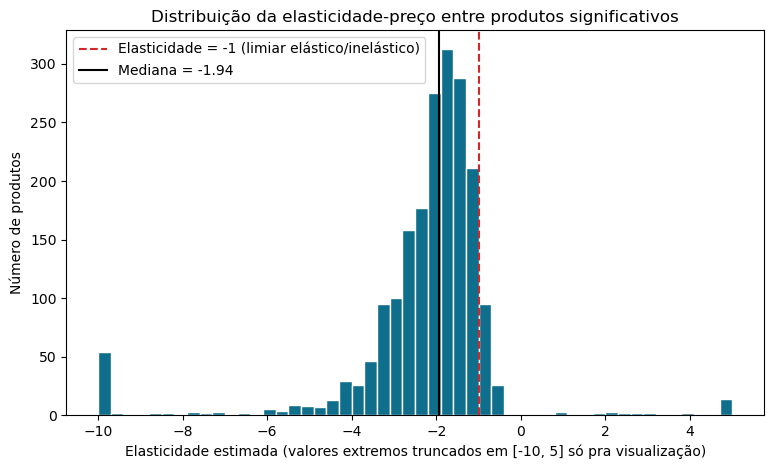

In [8]:
significativos = elasticidades[elasticidades['p_valor'] < 0.05]

print(f"Significativos (p<0,05): {len(significativos):,} de {len(elasticidades):,} ({len(significativos)/len(elasticidades):.1%})")
print(f"Desses, com sinal negativo (esperado): {(significativos['elasticidade'] < 0).mean():.1%}")
print(f"\nMediana da elasticidade (todos): {elasticidades['elasticidade'].median():.3f}")
print(f"Mediana da elasticidade (só significativos): {significativos['elasticidade'].median():.3f}")
print(f"\nDescribe (só significativos):")
print(significativos['elasticidade'].describe())

plt.figure(figsize=(9, 5))
plt.hist(significativos['elasticidade'].clip(-10, 5), bins=50, color='#0f6e8c', edgecolor='white')
plt.axvline(x=-1, color='tab:red', linestyle='--', label='Elasticidade = -1 (limiar elástico/inelástico)')
plt.axvline(x=significativos['elasticidade'].median(), color='black', linestyle='-', label=f"Mediana = {significativos['elasticidade'].median():.2f}")
plt.xlabel('Elasticidade estimada (valores extremos truncados em [-10, 5] só pra visualização)')
plt.ylabel('Número de produtos')
plt.title('Distribuição da elasticidade-preço entre produtos significativos')
plt.legend()
plt.show()

**E o R²?** A significância estatística (p-valor) diz se a elasticidade é confiável; o R² diz
**quanto da variação de vendas o preço sozinho explica**. São perguntas diferentes — vale checar
as duas.

In [9]:
print("R² — todos os produtos elegíveis:")
print(elasticidades['r2'].describe())
print("\nR² — só os estatisticamente significativos:")
print(significativos['r2'].describe())

R² — todos os produtos elegíveis:
count    3.280000e+03
mean     1.707239e-01
std      1.655013e-01
min      7.225417e-08
25%      3.963479e-02
50%      1.196697e-01
75%      2.529183e-01
max      9.154809e-01
Name: r2, dtype: float64

R² — só os estatisticamente significativos:
count    1994.000000
mean        0.255110
std         0.160252
min         0.037445
25%         0.128801
50%         0.213557
75%         0.343886
max         0.915481
Name: r2, dtype: float64


**Leitura honesta do R²:** mesmo entre os produtos com elasticidade estatisticamente
significativa, o R² mediano é de apenas **0,21** (variando de 0,13 a 0,34 no intervalo
interquartil) — bem melhor que o R²=0,046 do projeto de Precificação Dinâmica, mas ainda longe de
"o preço explica quase tudo". Isso faz sentido: preço é *um* fator de venda, não o único —
sazonalidade, disponibilidade de estoque, campanhas de marketing e tendência ao longo do tempo
também empurram a quantidade vendida, e nenhuma dessas variáveis está nesse modelo simples de
uma variável só. **A elasticidade pode ser real e estatisticamente confiável mesmo com R² baixo**
— confiabilidade do coeficiente (p-valor) e poder explicativo do modelo (R²) são coisas
diferentes, e é importante não confundir uma com a outra.

## 8. Achado honesto: cuidado com elasticidades extremas

Alguns produtos deram elasticidade absurda (ex: -78, o que significaria que um aumento de 10%
no preço derruba a demanda em 780% — impossível). Olhando esses casos de perto:

In [10]:
extremos = significativos[significativos['elasticidade'].abs() > 20].sort_values('n_semanas')
print(f"Produtos com |elasticidade| > 20: {len(extremos)}")
extremos[['StockCode', 'desc', 'n_semanas', 'elasticidade', 'r2']].head(10)

Produtos com |elasticidade| > 20: 28


,StockCode,desc,n_semanas,elasticidade,r2
3102,90018C,SILVER BLACK ORBIT DROP EARRINGS,18,23.377823,0.382370
3247,90205C,LARGE CRYSTAL DIAMANTE HAIRSLIDE,20,-26.259805,0.385086
3139,90094,NECKLACE+BRACELET SET FRUIT SALAD,23,-71.123808,0.248353
3215,90185B,AMETHYST DIAMANTE EXPANDABLE RING,24,25.530774,0.175461
3156,90122C,TURQUOISE CRYSTAL+GLASS BRACELET,24,-22.174028,0.216351
3232,90199C,5 STRAND GLASS NECKLACE CRYSTAL,24,-39.881638,0.428287
1922,23073,GEORGIAN TRINKET BOX,25,-44.004781,0.459120
3081,90002D,FLOWER BURST SILVER RING CRYSTAL,26,-36.787087,0.566611
671,21589,SWALLOW GIANT TUBE MATCHES,27,-25.457183,0.371663
3230,90198B,VINTAGE ROSE BEAD BRACELET BLACK,36,31.020243,0.146743


Confirma a suspeita: elasticidades extremas vêm de produtos com **poucas semanas de dado** —
regressão com pouca alavancagem (poucos pontos) é instável e sensível a outlier. A mediana
(seção 7) é uma estatística muito mais confiável que qualquer valor individual extremo.

## 9. Elasticidade agregada (robustez): regressão com efeito fixo por produto

Em vez de uma regressão por produto, junto os produtos de maior receita numa única regressão
com **dummy por produto** (efeito fixo) — controla pra diferenças de nível entre produtos e dá
uma estimativa única e mais robusta da elasticidade média.

In [11]:
data_clean['revenue'] = data_clean['Quantity'] * data_clean['Price']
top_receita = data_clean.groupby('StockCode')['revenue'].sum().sort_values(ascending=False).head(40).index

painel_top = painel[painel['StockCode'].isin(top_receita)].copy()
painel_top['log_qty'] = np.log(painel_top['qty'])
painel_top['log_price'] = np.log(painel_top['price'])

dummies = pd.get_dummies(painel_top['StockCode'], prefix='sc', drop_first=True)
X = pd.concat([painel_top[['log_price']], dummies], axis=1).astype(float)
X = sm.add_constant(X)

modelo_fe = sm.OLS(painel_top['log_qty'], X).fit()

print(f"n observações: {len(painel_top):,} (40 produtos de maior receita)")
print(f"Elasticidade (efeito fixo por produto): {modelo_fe.params['log_price']:.3f}")
print(f"p-valor: {modelo_fe.pvalues['log_price']:.2e}")
print(f"R²: {modelo_fe.rsquared:.3f}")

n observações: 3,615 (40 produtos de maior receita)
Elasticidade (efeito fixo por produto): -2.202
p-valor: 9.70e-79
R²: 0.452


**Por que conferir quais são esses 40 produtos antes de seguir para a simulação:** um R²=0,452 e
uma elasticidade de -2,20 não dizem nada, por si só, sobre *o quê* está gerando esse resultado.
Antes de confiar no número, vale checar a lista real — se são produtos genuinamente distintos
(não um código de frete que escapou da limpeza, nem SKUs duplicados da mesma peça) e se
representam uma variedade razoável do catálogo, não um grupo muito parecido entre si. Isso também
prepara o terreno pra seção 10, onde dois desses produtos são escolhidos pra uma simulação de
receita — melhor ver de onde eles vêm do que aparecerem do nada.

In [ ]:
produtos_top40 = (
    data_clean.groupby('StockCode')
    .agg(desc=('Description', 'first'), receita_total=('revenue', 'sum'))
    .loc[top_receita]
    .sort_values('receita_total', ascending=False)
)
produtos_top40

## 10. Simulação: para onde mover o preço?

Escolho dois produtos de destaque pra ilustrar a aplicação prática — um com demanda **elástica**
(|elasticidade| > 1) e outro com demanda **inelástica** (|elasticidade| < 1), os dois
estatisticamente significativos e com bastante histórico (mais confiáveis). Simulo receita
(preço × quantidade prevista) **dentro da faixa de preço já observada** — nada de extrapolar
preço muito além do que o produto já praticou.

**Ressalva importante:** num modelo log-log (elasticidade constante), a receita não tem máximo
interno quando a demanda é elástica — ela só cresce conforme o preço cai, sem limite matemático.
Isso não significa "baixe o preço a zero"; significa que esse modelo simples só é confiável
**dentro** da faixa de preço já testada pelo produto, não fora dela.

Produto elástico: 22423 REGENCY CAKESTAND 3 TIER elasticidade=-3.49
Produto inelástico: 22356 CHARLOTTE BAG , PINK/WHITE SPOTS elasticidade=-0.93


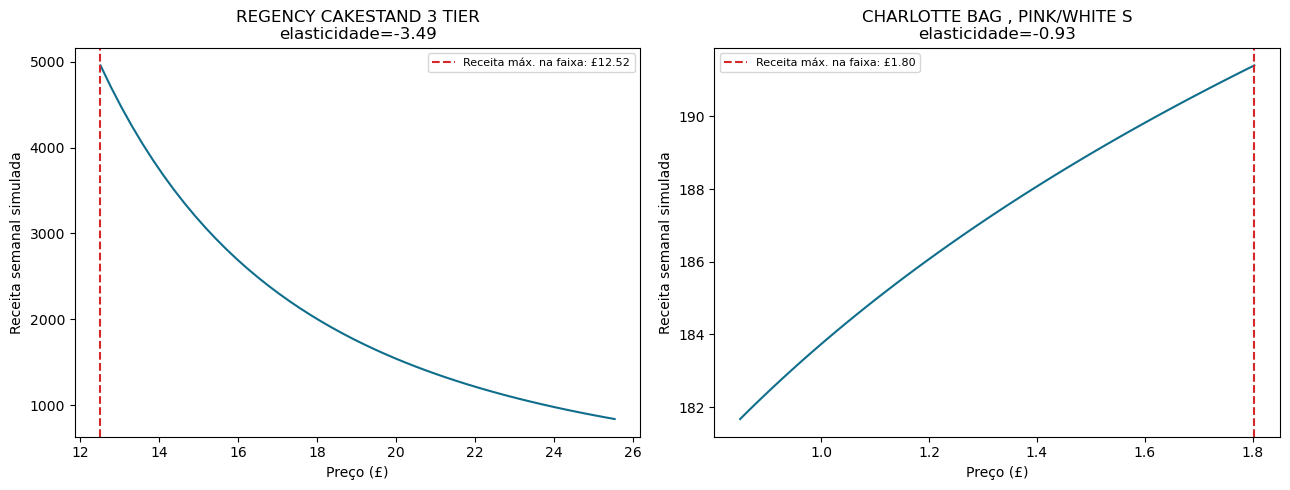

In [12]:
# produto elástico com mais receita
elastico_sc = significativos[significativos['elasticidade'] < -1].merge(
    data_clean.groupby('StockCode')['revenue'].sum().rename('receita_total'), on='StockCode'
).sort_values('receita_total', ascending=False).iloc[0]

# produto inelástico com mais semanas de dado (mais confiável)
inelastico_sc = significativos[(significativos['elasticidade'] > -1) & (significativos['elasticidade'] < 0)].sort_values('n_semanas', ascending=False).iloc[0]

print("Produto elástico:", elastico_sc['StockCode'], elastico_sc['desc'], f"elasticidade={elastico_sc['elasticidade']:.2f}")
print("Produto inelástico:", inelastico_sc['StockCode'], inelastico_sc['desc'], f"elasticidade={inelastico_sc['elasticidade']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, row in zip(axes, [elastico_sc, inelastico_sc]):
    sub = painel[painel['StockCode'] == row['StockCode']]
    preco_min, preco_max = sub['price'].min(), sub['price'].max()
    precos_sim = np.linspace(preco_min, preco_max, 50)

    X_sim = sm.add_constant(np.log(precos_sim), has_constant='add')
    modelo_sc = sm.OLS(np.log(sub['qty']), sm.add_constant(np.log(sub['price']))).fit()
    qty_sim = np.exp(modelo_sc.predict(X_sim))
    receita_sim = precos_sim * qty_sim

    ax.plot(precos_sim, receita_sim, color='#0f6e8c')
    ax.axvline(x=precos_sim[np.argmax(receita_sim)], color='tab:red', linestyle='--',
               label=f"Receita máx. na faixa: £{precos_sim[np.argmax(receita_sim)]:.2f}")
    ax.set_xlabel('Preço (£)')
    ax.set_ylabel('Receita semanal simulada')
    ax.set_title(f"{row['desc'][:28]}\nelasticidade={row['elasticidade']:.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Conclusões

**Resultado principal:** ao contrário do projeto de Precificação Dinâmica (elasticidade não
significativa, R² de 0,046), esse dataset entregou sinal real. De 3.281 produtos elegíveis,
**60,8% tiveram elasticidade estatisticamente significativa** (p<0,05), e destes, **98,3%** com
o sinal negativo esperado pela teoria econômica (preço sobe, demanda cai). A mediana da
elasticidade entre os significativos foi **-1,94** — demanda elástica, coerente com uma loja de
presentes/decoração (produtos com substitutos fáceis, não essenciais).

**Validação por dois métodos independentes:** a regressão com efeito fixo nos 40 produtos de
maior receita (seção 9) deu elasticidade de **-2,20** (p≈10⁻⁷⁹, R²=0,452) — na mesma faixa da
mediana individual (-1,94), confirmando o resultado com uma abordagem metodológica diferente.

**Por que esse dataset funcionou e o outro não:** a diferença não foi o método (log-log OLS é o
mesmo dos dois projetos) — foi a **variação de preço disponível nos dados**. O dataset de
Precificação Dinâmica tinha preço quase fixo por produto; este tem, em média, 4+ preços distintos
por produto ao longo de 2 anos. Elasticidade não é uma propriedade só do produto — é uma
propriedade que só é **observável** se existir variação de preço suficiente nos dados pra medi-la.

**Achado honesto sobre outliers:** 28 produtos deram elasticidades matematicamente impossíveis
(além de -20, incluindo um caso de -78) — todos com poucas semanas de histórico. Regressão com
poucos pontos é instável; a mediana (ou a regressão agregada com efeito fixo) é a estatística
confiável, não os extremos individuais.

**Aplicação prática (seção 10):** simulei receita dentro da faixa de preço já observada pra dois
produtos de perfis opostos —`REGENCY CAKESTAND 3 TIER` (elástico, -3,49) e `CHARLOTTE BAG,
PINK/WHITE SPOTS` (próximo do limiar, -0,93). Documentei a limitação técnica de que um modelo
log-log não tem máximo de receita interno quando a demanda é elástica — a simulação só vale
dentro da faixa de preço já testada, não como recomendação de extrapolar preço pra fora dela.

**Conexão com o objetivo original do portfólio:** esse é o primeiro projeto que efetivamente
demonstra o método originalmente proposto no início do portfólio — estimar elasticidade de
verdade e simular cenários de preço — algo que o projeto de Precificação Dinâmica (preço quase
fixo por veículo, dataset de corrida sintético) não permitia fazer com confiança estatística.

**Próximos passos possíveis:**
- Testar Lasso/XGBoost nesse painel maior, agora que existe sinal real pra comparar contra o OLS.
- Repetir a simulação de receita pra mais produtos, priorizando os de maior receita total.
- Investigar se a elasticidade varia por categoria de produto (`Description` sugere categorias
  implícitas — decoração, papelaria, bijuteria) usando os mesmos princípios da seção 9.

## 12. Insights

**Insight do projeto de Elasticidade-Preço da Demanda (Online Retail II):**

"Depois de rodar uma regressão por produto (R² mediano de 0,21) e ver esse número subir pra
0,452 quando agreguei os 40 produtos de maior receita numa regressão só com efeito fixo, percebi
que os dois resultados pareciam contradizer um ao outro — mas não contradizem. Investigando a
causa, achei duas explicações: o efeito fixo por produto absorve a diferença de nível de venda
entre produtos, meio que "de graça", sem o preço precisar explicar nada; e os 40 produtos de
maior receita são justamente o subconjunto com mais semanas de histórico e mais variação de
preço, ou seja, menos ruidoso que a base toda. Isso me mostrou, na prática, que R² não é uma
propriedade fixa de um fenômeno — é uma função da especificação do modelo e de qual amostra você
escolhe rodar. É a mesma lição do projeto de Precificação Dinâmica, onde uma única variável
categórica (`Vehicle_Type`) explicava quase todo o R², só que lá isso expunha um problema e aqui
era só o efeito esperado de agregar dados melhores.

Outro ponto que vale deixar registrado: a regressão por produto usa só uma variável (log do
preço) — ela me dá direção, magnitude e significância estatística da relação preço-demanda, mas
não controla sazonalidade, estoque ou campanha de marketing. É correlação, não causalidade
controlada: o coeficiente pode estar absorvendo parte desses fatores de fora do modelo. É
também por isso que o R² é baixo — não é falha do modelo, é o resultado esperado de deixar de
fora, de propósito, variáveis que sabidamente também mexem com a demanda."